# Introduction

This notebook is directly copy from my last work.

Link : [https://www.kaggle.com/code/wesleyhuan/easy-and-simple-solution-season-5-episode-12](http://)

This notebook will skip EDA and data visualization part. You can check it at the link above.

I ran into the problem that AUC is not imporving too much after hyperparameter(Optuna) and K-fold wasting too much time.

So I come up with 2 types of solution.

1. increase feature from correlation matrix(done)
2. OOF(Out-of-Fold)(done)

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import optuna
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder
from sklearn.model_selection import StratifiedKFold
# config
#torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
#print(device)
class CFG:
    train_csv = '/kaggle/input/playground-series-s5e12/train.csv'
    test_csv = '/kaggle/input/playground-series-s5e12/test.csv'
    sample_submission_csv = '/kaggle/input/playground-series-s5e12/sample_submission.csv'
    N_FOLDS = 5
    RANDOM_SEED = 42

# Load data

In [2]:
train = pd.read_csv(CFG.train_csv)
test = pd.read_csv(CFG.test_csv)

# Preprocess and clean data

**Why use a Class?**

State Retention: You need to remember the median values and the Encoders from the Training set so you can apply exactly the same rules to the Test set.


Avoids Leakage: Your previous function calculated the median of the test set using the test set. In a real scenario, you must use the training set's median to fill the test set.


Handles Unknowns: I replaced LabelEncoder with OrdinalEncoder. LabelEncoder crashes if the Test set has a category not seen in Train. OrdinalEncoder can be configured to handle these safely.

In [3]:
class DiabetesPreprocessor:
    def __init__(self):
        self.medians = {}
        self.encoders = {}
        self.numeric_cols = []
        self.categorical_cols = []
        
    def fit(self, df):
        """
        Learn the parameters (medians, categories) from the TRAINING data.
        """
        # Identify columns
        self.numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        self.categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
        
        # 1. Learn Medians for numeric columns
        for col in self.numeric_cols:
            self.medians[col] = df[col].median()
            
        # 2. Fit Encoders for categorical columns
        # handle_unknown='use_encoded_value' prevents crashes if Test data has new categories
        for col in self.categorical_cols:
            enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            # We must reshape to (-1, 1) for sklearn encoders
            enc.fit(df[[col]].astype(str)) 
            self.encoders[col] = enc
            
        return self

    def transform(self, df):
        """
        Apply the learned parameters to the data (Train or Test).
        """
        df = df.copy()
        
        # 1. Drop irrelevant columns (ID is usually dropped, Target handled separately)
        # Note: We don't drop target here to keep X and y aligned until the end
        if 'id' in df.columns:
            df = df.drop(columns=['id'])
            
        # 2. Impute Missing Values using LEARNED medians
        for col in self.numeric_cols:
            if col in df.columns:
                df[col] = df[col].fillna(self.medians.get(col, 0))
        
        # 3. Apply Encoding
        for col in self.categorical_cols:
            if col in df.columns:
                # Fill NaN in categoricals with 'Missing' before encoding to be safe
                df[col] = df[col].astype(str).fillna('Missing')
                df[col] = self.encoders[col].transform(df[[col]])
        
        return df
        
    def create_interaction_features(self, df):# add because of the Correlation matrix
        df = df.copy()
        
        # 1. Pulse Pressure (Heart/Artery stress)
        # Higher pulse pressure is linked to diabetes complications
        if 'systolic_bp' in df.columns and 'diastolic_bp' in df.columns:
            df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']
            
        # 2. Cholesterol Ratios (Metabolic health)
        # Avoid division by zero by adding a tiny epsilon if needed, 
        # though HDL is rarely 0 in real data.
        if 'cholesterol_total' in df.columns and 'hdl_cholesterol' in df.columns:
            df['cholesterol_ratio'] = df['cholesterol_total'] / (df['hdl_cholesterol'] + 1e-5)
            
        if 'ldl_cholesterol' in df.columns and 'hdl_cholesterol' in df.columns:
            df['ldl_hdl_ratio'] = df['ldl_cholesterol'] / (df['hdl_cholesterol'] + 1e-5)
    
        # 3. Visceral Fat Proxy (The "Bad" Fat)
        # Combining general obesity (BMI) with central obesity (Waist)
        if 'bmi' in df.columns and 'waist_to_hip_ratio' in df.columns:
            df['visceral_fat_index'] = df['bmi'] * df['waist_to_hip_ratio']
            
        # 4. Activity-to-Screen Ratio
        # Measures sedentary lifestyle balance
        if 'physical_activity_minutes_per_week' in df.columns and 'screen_time_hours_per_day' in df.columns:
            # Convert screen time to minutes to make units comparable
            screen_mins = df['screen_time_hours_per_day'] * 60
            df['activity_screen_ratio'] = df['physical_activity_minutes_per_week'] / (screen_mins + 1)
        
        # Interaction: Age and systolic_bp have 0.5 correlation 
        if 'age' in df.columns and 'systolic_bp' in df.columns:
            df['age_systolic_bp_interaction'] = df['age'] * df['systolic_bp']

        # Interaction: triglycerides and BMI have 0.44 correlation 
        if 'triglycerides' in df.columns and 'BMI' in df.columns:
            df['triglycerides_BMI_interaction'] = df['triglycerides'] * df['BMI']
            
        return df

In [4]:
# Initialize the preprocessor
preprocessor = DiabetesPreprocessor()

# Separate Target from Train for fitting (optional, but cleaner)
# It is best to calculate stats on the features, not including the target
X_train_raw = train.drop(columns=['diagnosed_diabetes'])
y_train = train['diagnosed_diabetes']
test_ids = test['id']

# FIT on Training Data Only (Learn the rules)
preprocessor.fit(X_train_raw)

# TRANSFORM both Train and Test (Apply the rules)
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(test)

X_train_add_feature = preprocessor.create_interaction_features(X_train_processed)
X_test_add_feature = preprocessor.create_interaction_features(X_test_processed)

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


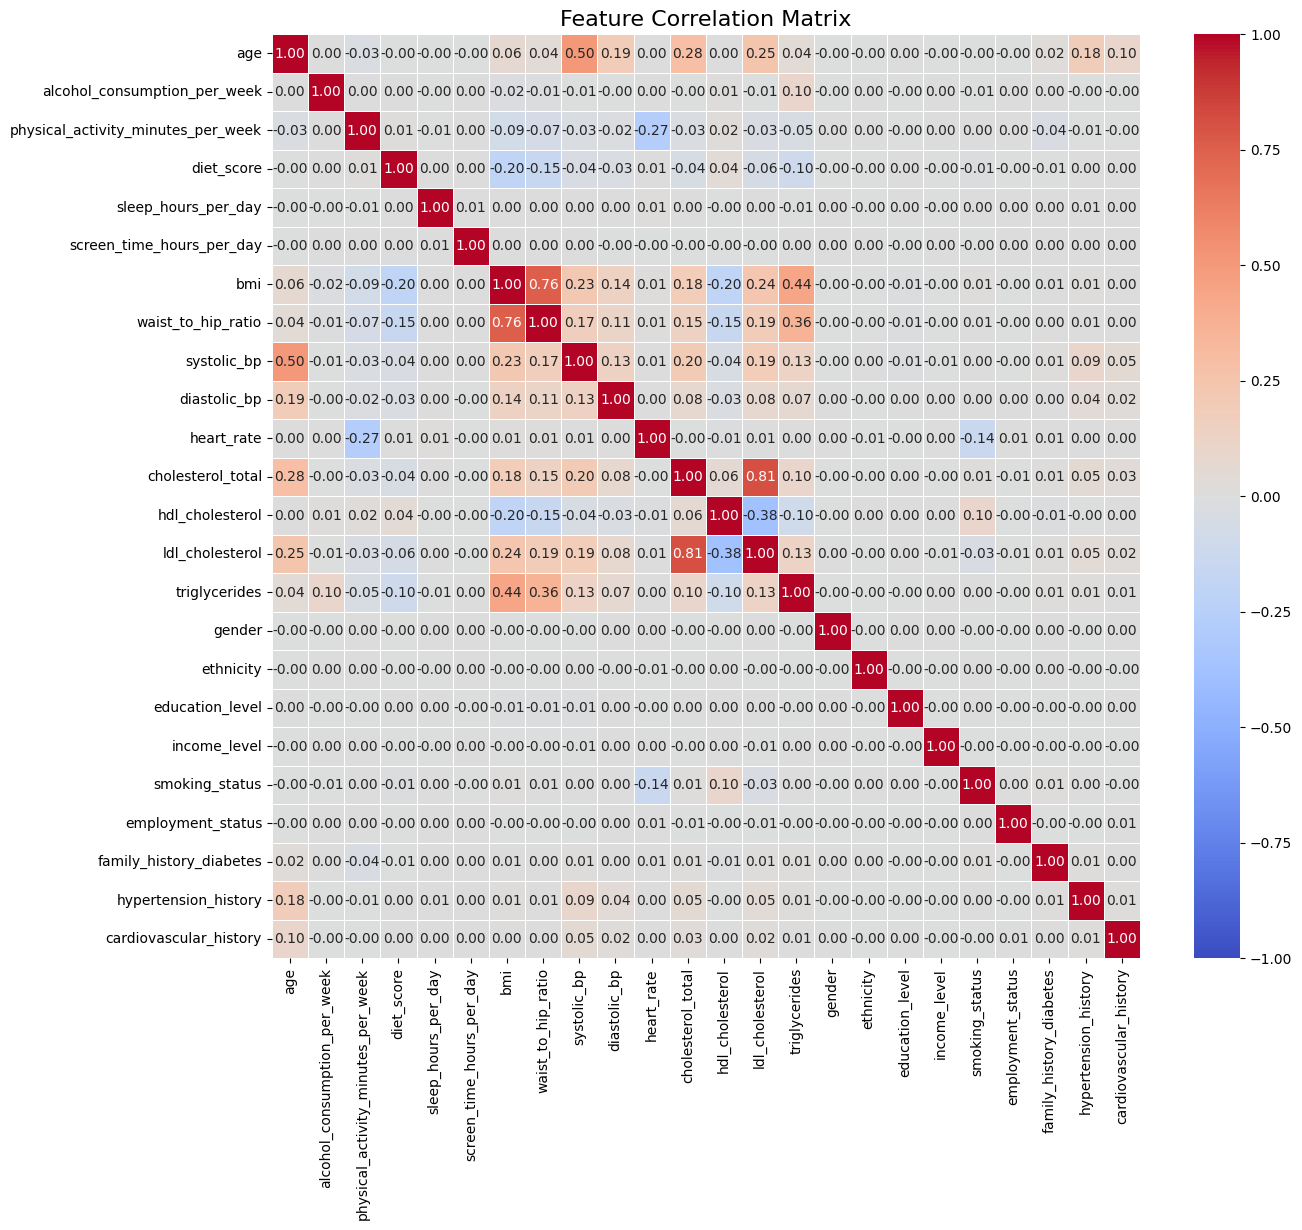

In [5]:
# 1. Calculate the correlation matrix
# We use the processed data so categorical columns (encoded as numbers) are included
corr_matrix = X_train_processed.corr()

# 2. Setup the figure size (make it large enough to read)
plt.figure(figsize=(14, 12))

# 3. Create the Heatmap
# annot=True: shows the numbers
# cmap='coolwarm': Blue for negative corr, Red for positive
# fmt=".2f": limits decimals to 2 places
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

Strategy 1: The "Difference" Feature (Blood Pressure)

What to look for: Look at **systolic_bp** and **diastolic_bp**. 

Observation: They will likely be highly correlated (red square) because if one is high, the other is usually high. In this data it seems like they don't. Instead of **systolic_bp** and **diastolic_bp** **age** seems have more  relation.

The New Feature: The gap between them is medically significant. It's called Pulse Pressure. A widening gap indicates stiffening arteries, which is a diabetes risk factor.

Strategy 2: The "Ratio" Feature (Cholesterol)

What to look for: Look at **ldl_cholesterol**, **hdl_cholesterol**, and **cholesterol_total**. 

Observation: They might have strong correlations. The New Feature: In medicine, the balance between "bad" (LDL) and "good" (HDL) cholesterol is a better predictor of heart/metabolic health than just the total number.

Strategy 3: The "Interaction" Feature (BMI & Waist)

What to look for: **bmi** and **waist_to_hip_ratio**. 

Observation: Both measure obesity, so they will be correlated. The New Feature: A person can have a high BMI but be muscular (low risk). However, if they have high BMI AND a high Waist-to-Hip ratio, that indicates Visceral Fat (fat around organs), which is the #1 driver of Type 2 Diabetes.


# Train model with Hyper parameter (OPTUNA)


In [6]:
X_tuning, _, y_tuning, _ = train_test_split(
    X_train_add_feature, y_train, 
    train_size=0.5, # Tune on 40% of data
    stratify=y_train, 
    random_state=CFG.RANDOM_SEED
)

# Define the number of folds
def objective_cv(trial, X, y, n_folds=CFG.N_FOLDS, random_seed=CFG.RANDOM_SEED):
    """
    Optuna objective function that uses Stratified K-Fold Cross-Validation.
    """
    # 1. Define Hyperparameters using Optuna trial suggestions
    param = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "use_label_encoder": False,
        "tree_method": 'hist', # Faster training method
        "booster": 'gbtree',
        "random_state": random_seed,
        
        # Hyperparameters to tune
        "max_depth": trial.suggest_int("max_depth", 4, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True), # Use log scale for LR
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
    }

    # 2. Setup Stratified K-Fold
    # Ensure stable splits regardless of data size
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_seed)
    auc_scores = []
    
    # 3. Training Loop (Cross-Validation)
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Instantiate and train model
        model = xgb.XGBClassifier(**param)
        model.fit(
            X_train, y_train,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        # Predict probabilities and calculate AUC for this fold
        y_pred_prob = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred_prob)
        auc_scores.append(auc)
        
    # 4. Return the mean AUC across all folds
    mean_auc = np.mean(auc_scores)
    #Print the result for the current trial
    print(f"Trial {trial.number:3d} finished with mean CV AUC: {mean_auc:.6f}")
    
    return mean_auc


train_x = X_train_add_feature 
train_y = y_train 
# Build and run Optuna study
print("Starting Optuna study with Stratified K-Fold...")
study = optuna.create_study(direction="maximize")  # Maximize the mean AUC
# Pass the full training data (X and y) to the objective function
study.optimize(lambda trial: objective_cv(trial, X_tuning, y_tuning), n_trials=30)
print("Study complete.")

# Result
print("\n🎉 Best parameters found by CV Optuna:")
print(study.best_params)
print(f"Best Mean CV AUC: {study.best_value:.4f}")

[I 2026-01-04 23:45:23,963] A new study created in memory with name: no-name-c7f0adb5-1956-48ea-bfcb-00bedf9b3eda


Starting Optuna study with Stratified K-Fold...


[I 2026-01-04 23:46:54,163] Trial 0 finished with value: 0.719863850641352 and parameters: {'max_depth': 9, 'learning_rate': 0.0572315656388437, 'n_estimators': 300, 'subsample': 0.8235621463281151, 'colsample_bytree': 0.8512635195559197, 'min_child_weight': 4, 'gamma': 5.800468587802734e-08, 'reg_alpha': 3.9191734781241245e-06, 'reg_lambda': 0.0008283368976815717}. Best is trial 0 with value: 0.719863850641352.


Trial   0 finished with mean CV AUC: 0.719864


[I 2026-01-04 23:48:04,374] Trial 1 finished with value: 0.7087252162249393 and parameters: {'max_depth': 5, 'learning_rate': 0.014705382512882203, 'n_estimators': 300, 'subsample': 0.9662142578326379, 'colsample_bytree': 0.665294039525338, 'min_child_weight': 8, 'gamma': 1.7740719235921342e-05, 'reg_alpha': 0.26556029699067324, 'reg_lambda': 1.6978594501070174e-05}. Best is trial 0 with value: 0.719863850641352.


...

Trial  27 finished with mean CV AUC: 0.721953


[I 2026-01-05 00:59:56,205] Trial 28 finished with value: 0.7204676554053362 and parameters: {'max_depth': 4, 'learning_rate': 0.059876374242027, 'n_estimators': 450, 'subsample': 0.8916338594285231, 'colsample_bytree': 0.6827650524954376, 'min_child_weight': 3, 'gamma': 1.124777371740057e-08, 'reg_alpha': 0.003244339427448958, 'reg_lambda': 3.866671978064673e-05}. Best is trial 11 with value: 0.7240376466523623.


Trial  28 finished with mean CV AUC: 0.720468


[I 2026-01-05 01:00:32,520] Trial 29 finished with value: 0.7174206417548035 and parameters: {'max_depth': 9, 'learning_rate': 0.03915892884999645, 'n_estimators': 100, 'subsample': 0.8261305553060974, 'colsample_bytree': 0.6221776064900086, 'min_child_weight': 4, 'gamma': 4.901696723554594e-08, 'reg_alpha': 8.81035185540002e-06, 'reg_lambda': 0.0003114071357019948}. Best is trial 11 with value: 0.7240376466523623.


Trial  29 finished with mean CV AUC: 0.717421
Study complete.

🎉 Best parameters found by CV Optuna:
{'max_depth': 4, 'learning_rate': 0.07551315438521473, 'n_estimators': 1000, 'subsample': 0.8696238919679042, 'colsample_bytree': 0.6157916498220208, 'min_child_weight': 2, 'gamma': 4.0629565261717865e-08, 'reg_alpha': 0.00013241592047781995, 'reg_lambda': 0.0012497952125293515}
Best Mean CV AUC: 0.7240


# Submission

In [7]:
# 建議修改的最後訓練階段
def train_and_predict(X, y, X_test, params):
    kf = StratifiedKFold(n_splits=CFG.N_FOLDS, shuffle=True, random_state=CFG.RANDOM_SEED)
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(X_test))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params, tree_method='hist', random_state=CFG.RANDOM_SEED)
        
        # 增加早停機制 (Early Stopping) 防止過擬合
        model.fit(X_tr, y_tr, 
                  eval_set=[(X_val, y_val)], 
                  verbose=False)
        
        # 預測驗證集與測試集
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        test_preds += model.predict_proba(X_test)[:, 1] / CFG.N_FOLDS
        
        print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, oof_preds[val_idx]):.6f}")
        
    print(f"Overall OOF AUC: {roc_auc_score(y, oof_preds):.6f}")
    return test_preds

# 使用 Optuna 找到的最佳參數執行
final_test_preds = train_and_predict(train_x, train_y, X_test_add_feature, study.best_params)

# 更新提交
submission = pd.DataFrame({
    'id': test['id'],  # Use the original IDs from the test set
    'diagnosed_diabetes': final_test_preds
})
submission.to_csv('submission.csv', index=False)

print("\nSubmission file created: cv_optuna_submission.csv")

print(f"Submission file created: {submission.shape}")
print("First 5 rows of submission:")
print(submission.head())

Fold 1 AUC: 0.726336
Fold 2 AUC: 0.724703
Fold 3 AUC: 0.725630
Fold 4 AUC: 0.727048
Fold 5 AUC: 0.726022
Overall OOF AUC: 0.725945

Submission file created: cv_optuna_submission.csv
Submission file created: (300000, 2)
First 5 rows of submission:
       id  diagnosed_diabetes
0  700000            0.479891
1  700001            0.673451
2  700002            0.783026
3  700003            0.400389
4  700004            0.928894
